# EDA for `target/hf_15m`

Simple exploratory data analysis for the 15-minute dataset generated by `okx-highfrequency`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", 50)

In [2]:
def resolve_data_path() -> Path:
    p = Path("target/hf_15m")
    if p.is_file():
        return p
    csv_candidate = p.with_suffix(".csv")
    if csv_candidate.is_file():
        return csv_candidate
    if p.is_dir():
        csv_files = sorted(p.glob("*.csv"))
        if csv_files:
            return csv_files[0]
    raise FileNotFoundError("Could not find target/hf_15m(.csv)")

data_path = resolve_data_path()
data_path

WindowsPath('target/hf_15m.csv')

In [3]:
df = pd.read_csv(data_path, parse_dates=["DT"])
df = df.sort_values("DT").reset_index(drop=True)

numeric_cols = ["TIMESTAMP", "PRICE", "SIZE", "BID", "OFR", "BIDSIZ", "OFRSIZ", "MIDQUOTE"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded {data_path} with shape={df.shape}")
df.head()

Loaded target\hf_15m.csv with shape=(2975, 11)


,DT,TIMESTAMP,EX,SYMBOL,PRICE,SIZE,BID,OFR,BIDSIZ,OFRSIZ,MIDQUOTE
0,2025-10-01 00:15:00+00:00,1759277700000,OKX,BTC-USDT,114157.95,30.311931,114157.9,114158.0,1.032116,0.423712,114157.95
1,2025-10-01 00:30:00+00:00,1759278600000,OKX,BTC-USDT,114015.95,46.947986,114015.9,114016.0,0.505013,1.000213,114015.95
2,2025-10-01 00:45:00+00:00,1759279500000,OKX,BTC-USDT,113969.65,24.070028,113969.6,113969.7,2.339611,0.171511,113969.65
3,2025-10-01 01:00:00+00:00,1759280400000,OKX,BTC-USDT,114236.45,30.793658,114236.4,114236.5,1.016301,0.608908,114236.45
4,2025-10-01 01:15:00+00:00,1759281300000,OKX,BTC-USDT,114342.65,38.400451,114342.6,114342.7,1.054002,0.994652,114342.65


In [4]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "nunique": df.nunique(dropna=True),
    }
)

print(f"Date range: {df['DT'].min()} -> {df['DT'].max()}")
display(summary)
display(df[numeric_cols].describe().T)

Date range: 2025-10-01 00:15:00+00:00 -> 2025-10-31 23:45:00+00:00


,dtype,missing,nunique
DT,"datetime64[ns, UTC]",0,2975
TIMESTAMP,int64,0,2975
EX,object,0,1
SYMBOL,object,0,1
PRICE,float64,0,2915
SIZE,float64,0,2975
BID,float64,0,2914
OFR,float64,0,2915
BIDSIZ,float64,0,2969
OFRSIZ,float64,0,2968


,count,mean,std,min,25%,50%,75%,max
TIMESTAMP,2975.0,1.760616e+12,7.730576e+08,1.759278e+12,1.759947e+12,1.760616e+12,1.761285e+12,1.761954e+12
PRICE,2975.0,1.142454e+05,5.550711e+03,1.040076e+05,1.101191e+05,1.124801e+05,1.200014e+05,1.260124e+05
SIZE,2975.0,9.315708e+01,1.418016e+02,2.491958e+00,3.279313e+01,5.818195e+01,1.065818e+02,4.861808e+03
BID,2975.0,1.142453e+05,5.550728e+03,1.040076e+05,1.101191e+05,1.124800e+05,1.200014e+05,1.260124e+05
OFR,2975.0,1.142454e+05,5.550694e+03,1.040077e+05,1.101192e+05,1.124801e+05,1.200015e+05,1.260125e+05
BIDSIZ,2975.0,5.828976e-01,8.881763e-01,1.000000e-05,1.573087e-01,4.299435e-01,7.894700e-01,2.315850e+01
OFRSIZ,2975.0,6.019709e-01,9.516016e-01,1.000000e-05,1.493732e-01,4.204417e-01,7.872567e-01,2.428309e+01
MIDQUOTE,2975.0,1.142454e+05,5.550711e+03,1.040076e+05,1.101191e+05,1.124801e+05,1.200014e+05,1.260124e+05


In [5]:
duplicate_rows = int(df.duplicated().sum())
duplicate_dt = int(df["DT"].duplicated().sum())
dt_diff = df["DT"].diff().dropna()

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate timestamps: {duplicate_dt}")
print("Top timestamp intervals:")
display(dt_diff.value_counts().head(10))

Duplicate rows: 0
Duplicate timestamps: 0
Top timestamp intervals:


DT
0 days 00:15:00    2974
Name: count, dtype: int64

In [6]:
df["spread"] = df["OFR"] - df["BID"]
df["ret_1"] = df["MIDQUOTE"].pct_change()
df["log_ret_1"] = np.log(df["MIDQUOTE"]).diff()
df["size_z"] = (df["SIZE"] - df["SIZE"].mean()) / df["SIZE"].std(ddof=0)

display(df[["DT", "MIDQUOTE", "spread", "ret_1", "SIZE", "size_z"]].head())
display(df[["spread", "ret_1", "log_ret_1", "size_z"]].describe().T)

,DT,MIDQUOTE,spread,ret_1,SIZE,size_z
0,2025-10-01 00:15:00+00:00,114157.95,0.1,NaN,30.311931,-0.443265
1,2025-10-01 00:30:00+00:00,114015.95,0.1,-0.001244,46.947986,-0.325926
2,2025-10-01 00:45:00+00:00,113969.65,0.1,-0.000406,24.070028,-0.487291
3,2025-10-01 01:00:00+00:00,114236.45,0.1,0.002341,30.793658,-0.439867
4,2025-10-01 01:15:00+00:00,114342.65,0.1,0.000930,38.400451,-0.386214


,count,mean,std,min,25%,50%,75%,max
spread,2975.0,1.418487e-01,1.466224,0.100000,0.100000,0.100000,0.100000,70.600000
ret_1,2974.0,-1.052693e-05,0.002456,-0.032978,-0.001069,-0.000009,0.001099,0.021694
log_ret_1,2974.0,-1.354741e-05,0.002459,-0.033534,-0.001070,-0.000009,0.001099,0.021462
size_z,2975.0,-1.122538e-16,1.000168,-0.639487,-0.425764,-0.246690,0.094688,33.634676


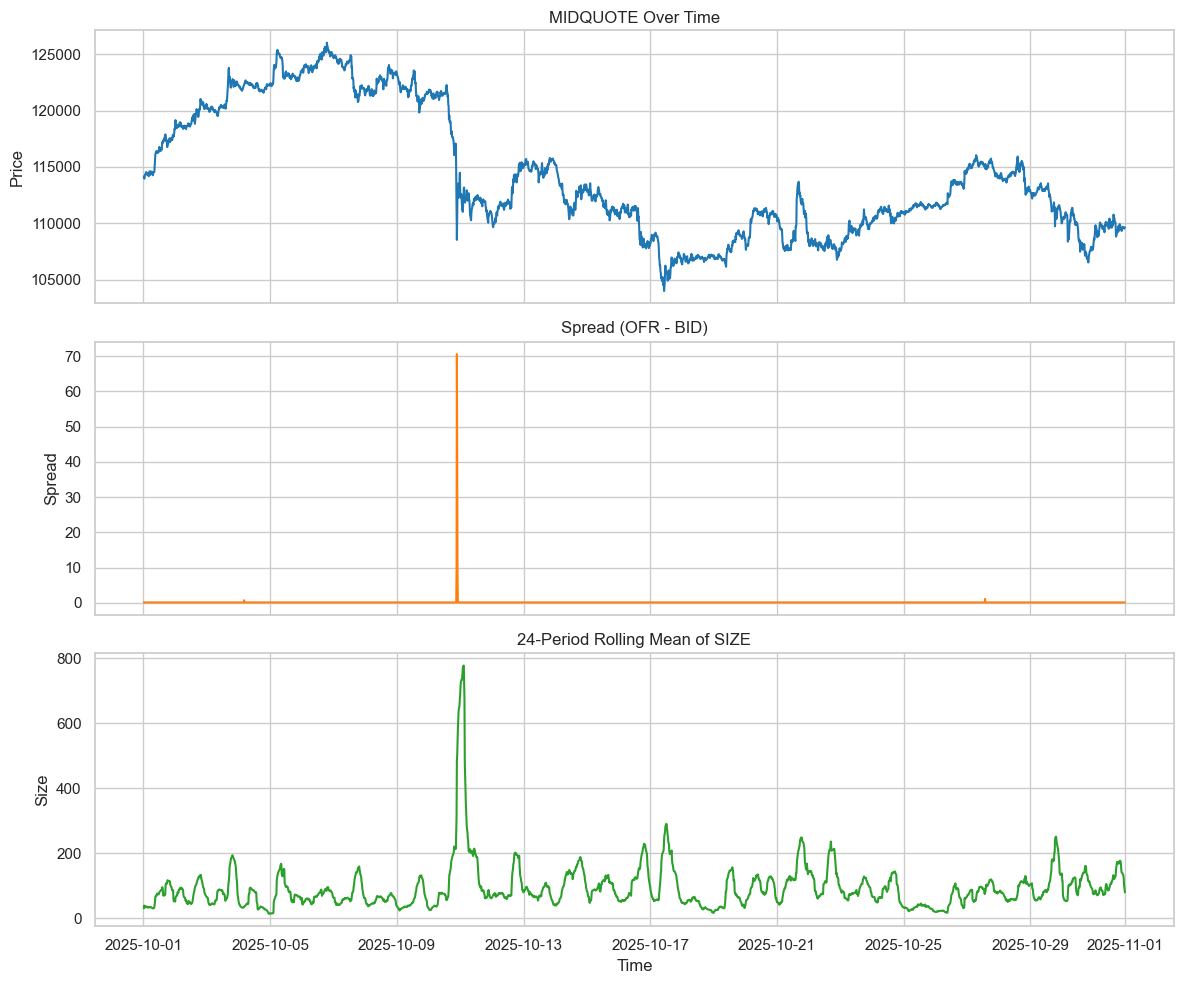

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df["DT"], df["MIDQUOTE"], color="tab:blue")
axes[0].set_title("MIDQUOTE Over Time")
axes[0].set_ylabel("Price")

axes[1].plot(df["DT"], df["spread"], color="tab:orange")
axes[1].set_title("Spread (OFR - BID)")
axes[1].set_ylabel("Spread")

axes[2].plot(df["DT"], df["SIZE"].rolling(24, min_periods=1).mean(), color="tab:green")
axes[2].set_title("24-Period Rolling Mean of SIZE")
axes[2].set_ylabel("Size")
axes[2].set_xlabel("Time")

plt.tight_layout()
plt.show()

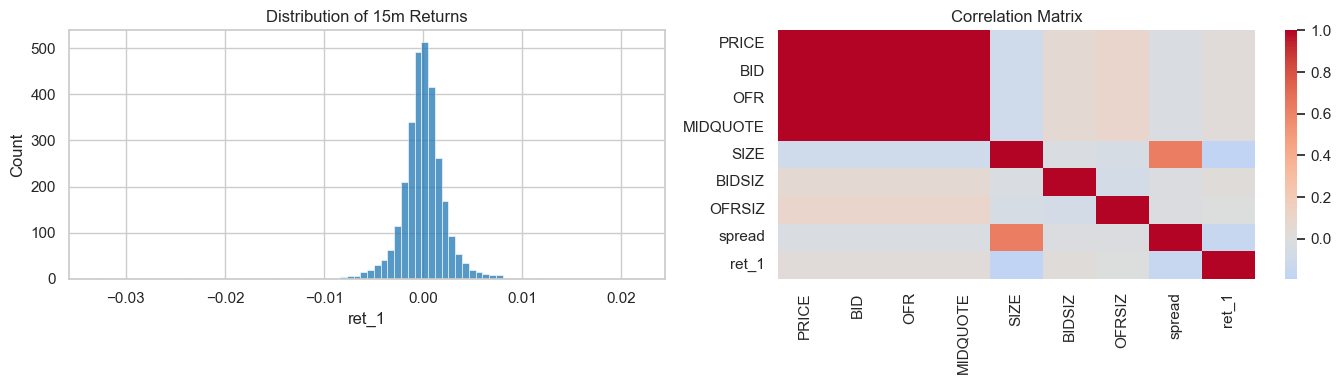

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["ret_1"].dropna(), bins=80, ax=axes[0], color="tab:blue")
axes[0].set_title("Distribution of 15m Returns")
axes[0].set_xlabel("ret_1")

corr_cols = ["PRICE", "BID", "OFR", "MIDQUOTE", "SIZE", "BIDSIZ", "OFRSIZ", "spread", "ret_1"]
corr = df[corr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [9]:
q_low, q_high = df["ret_1"].quantile([0.01, 0.99])
tail_events = df[(df["ret_1"] < q_low) | (df["ret_1"] > q_high)][["DT", "MIDQUOTE", "ret_1", "SIZE", "spread"]]

print(f"Tail-return events: {len(tail_events)} ({len(tail_events) / len(df):.2%})")
tail_events.head(20)

Tail-return events: 60 (2.02%)


,DT,MIDQUOTE,ret_1,SIZE,spread
256,2025-10-03 16:15:00+00:00,123100.05,0.006778,477.635357,0.1
259,2025-10-03 17:00:00+00:00,122560.05,-0.009919,404.570655,0.1
403,2025-10-05 05:00:00+00:00,125181.35,0.007090,1030.302474,0.1
422,2025-10-05 09:45:00+00:00,122986.95,-0.008306,424.713696,0.1
630,2025-10-07 13:45:00+00:00,123791.95,-0.008150,297.275772,0.1
632,2025-10-07 14:15:00+00:00,122838.55,-0.008529,261.171054,0.1
706,2025-10-08 08:45:00+00:00,122827.95,0.007514,196.857651,0.1
835,2025-10-09 17:00:00+00:00,119824.95,-0.008141,338.505051,0.1
923,2025-10-10 15:00:00+00:00,120492.95,-0.007100,171.109894,0.1
925,2025-10-10 15:30:00+00:00,119233.05,-0.009865,720.403711,0.1
